## Libaries

In [61]:
import os
import numpy as np
import mne
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## GOBAL VARIABLES

In [ ]:
DATASET_PATH = "BCI2a_dataset"
FS = 250  # Sampling frequency

# Time window (seconds)             # LOOK INTO THIS
TMIN = 0.0     # start at cue
TMAX = 6.0     # 4 seconds MI
ONSET_TMIN = 0.0          # onset window
ONSET_TMAX = 3.0

BANDPASS = (8, 32)  # mu + beta band

## UTILITY FUNCITOSN

In [50]:
def bandpass_filter(data, fs, low, high, order=4):
    """
    Zero-phase Butterworth bandpass filter
    data: (samples, channels)
    """
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, data, axis=0)


def standardize_epochs(X):
    """
    Channel-wise z-score normalization
    X shape: (trials, samples, channels)
    """
    Xn = np.zeros_like(X)
    for ch in range(X.shape[2]):
        scaler = StandardScaler()
        Xn[:, :, ch] = scaler.fit_transform(X[:, :, ch])
    return Xn


In [120]:
#=============#
# CORE LOADER #
#=============#
# Input varaibles
subject_id = 1
train = True


mode = "T" if train else "E"
fname = f"A{subject_id:02d}{mode}.gdf"
filepath = os.path.join(DATASET_PATH, fname)

# Load GDF file
raw = mne.io.read_raw_gdf(filepath, preload=True, verbose=False)

# Drop EOG channels
eeg_chs = raw.info["ch_names"][:22]
raw.pick(eeg_chs)

# Extract events
events, event_id = mne.events_from_annotations(raw)

mi_event_ids = {
    event_id['769']: 0,  # left hand
    #event_id['770']: 1,  # right hand
}

C:\Users\Bruger\AppData\Local\Programs\Python\Python311\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']


In [124]:
# NOT SURE IF THIS IS RIGHT

# keep only MI events
mask = np.isin(events[:, 2], list(mi_event_ids.keys()))
events_mi = events[mask]

# extract labels
#y = np.array([mi_event_ids[e] for e in events_mi[:, 2]])

# Epoching
epochs = mne.Epochs(
    raw,
    events_mi,
    event_id={
        'left_hand':  event_id['769'],
        #'right_hand': event_id['770'],
    },
    tmin=TMIN,
    tmax=TMAX,
    baseline=None,
    preload=True,
    verbose=False
)

epochs_onset = epochs.copy().crop(tmin=ONSET_TMIN, tmax = ONSET_TMAX)


In [157]:
X = epochs_onset.get_data()           # (trials, channels, samples)
X = np.transpose(X, (0, 2, 1))  # Reorder to (trials, samples, channels)

continous_datastream = epochs.get_data()                                # (trials, channels, samples)
continous_datastream = np.transpose(continous_datastream, (0, 2, 1))    # Reorder to (trials, samples, channels)

# Labels (single source of truth)
y = np.array([mi_event_ids[e] for e in epochs.events[:, 2]])


for i in range(X.shape[0]):
    X[i] = bandpass_filter(X[i], FS, BANDPASS[0], BANDPASS[1])

# Normalize
X = standardize_epochs(X)

print(X.shape)           # (n_trials, time, 22)
print(np.unique(y))      # [0 1 2 3]
assert len(X) == len(y)

(71, 751, 22)
[0]


## PLOT FUNCTIONS

In [192]:
def plot_mean_epoch(X, fs, ch_idx=10):
    """
    Plot mean onset response for one channel
    """
    time = np.arange(X.shape[1]) / fs
    mean_sig = X[:, :, ch_idx].mean(axis=0)

    plt.figure(figsize=(8, 4))
    plt.plot(time, mean_sig)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Mean LEFT-hand onset (Channel {ch_idx})")
    plt.tight_layout()
    plt.show()


def plot_continuous_with_markers(raw, events, event_id, ch_idx=10, fs=250, window=[0, -1]):
    # data = raw.get_data()[ch_idx]
    st = window[0]
    ed = window[1]
    data = raw[st*fs:ed*fs, ch_idx]
    time = np.arange(len(data)) / fs
    print(data.shape)
    plt.figure(figsize=(14, 4))
    plt.plot(time, data, linewidth=0.5)

    # for ev in events:
    #     if ev[2] == event_id['769']:  # left hand
    #         print(ev[0])
    #         t = ev[0] / fs
    #         plt.axvline(t, color='red', linestyle='--', alpha=0.4)

    # plt.xlim(st, ed)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Continuous EEG with LEFT-hand cue markers")
    plt.tight_layout()
    plt.show()



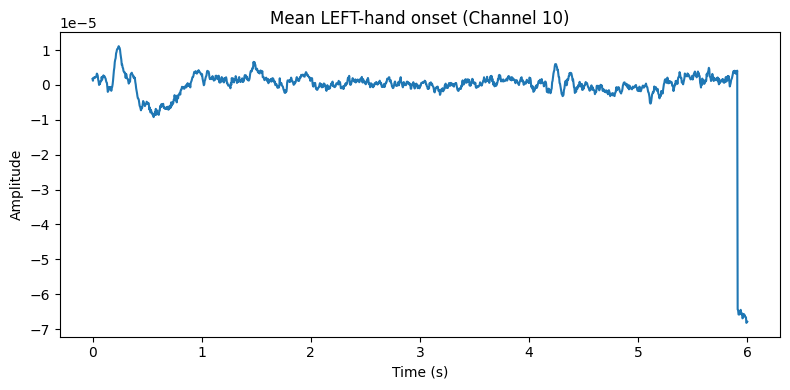

(3000,)


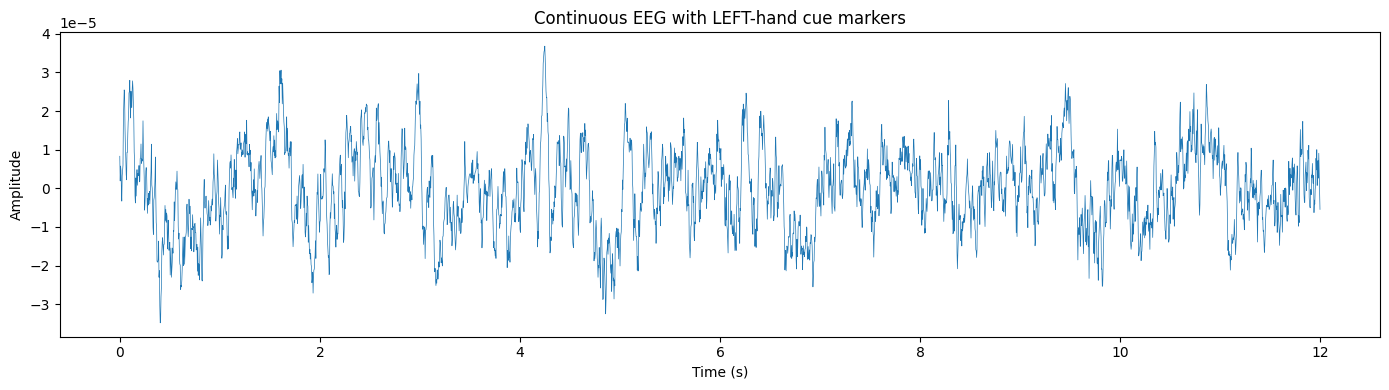

In [197]:
plot_mean_epoch(continous_datastream, fs=250, ch_idx=10)
# plot_mean_epoch(continous_datastream, fs=250, ch_idx=3)
plot_continuous_with_markers(continous_datastream.reshape(-1, 22), events, event_id, ch_idx=10, fs=250, window = [0, 12])


In [195]:
6*12

72

In [214]:
#=============#
# CORE LOADER #
#=============#
def load_subject(subject_id, sel_mode, sel_class_type):
    '''
    Parameters
    ----------
    sel_class_type : str
        '769' for left hand MI
        '770' for right hand MI
    '''
    FS = 250  # Sampling frequency
    TMIN = 0.0              # start at cue
    TMAX = 6.0              # 4 seconds MI
    ONSET_TMIN = 0.0        # onset window
    ONSET_TMAX = 3.0        # End of onset
    BANDPASS = (8, 32)  # mu + beta band

    mode = "T" if sel_mode else "E"
    fname = f"A{subject_id:02d}{mode}.gdf"
    filepath = os.path.join(DATASET_PATH, fname)

    # Load GDF file
    raw = mne.io.read_raw_gdf(filepath, preload=True, verbose=False)

    # Drop EOG channels
    eeg_chs = raw.info["ch_names"][:22]
    raw.pick(eeg_chs)

    # Extract events
    events, event_id = mne.events_from_annotations(raw)

    class_type = event_id[sel_class_type]

    # keep only MI events
    mask = np.isin(events[:, 2], list(mi_event_ids.keys()))
    events_mi = events[mask]

    # Epoching
    epochs = mne.Epochs(
        raw,
        events_mi,
        event_id={'hand_motion': class_type},
        tmin=TMIN,
        tmax=TMAX,
        baseline=None,
        preload=True,
        verbose=False
    )

    # crop to only onset
    epochs_onset = epochs.copy().crop(tmin=ONSET_TMIN, tmax = ONSET_TMAX)

    X = epochs_onset.get_data()           # (trials, channels, samples)
    X = np.transpose(X, (0, 2, 1))  # Reorder to (trials, samples, channels)

    continous_datastream = epochs.get_data()                                # (trials, channels, samples)
    continous_datastream = np.transpose(continous_datastream, (0, 2, 1))    # Reorder to (trials, samples, channels)

    # Labels (single source of truth)
    y = np.array([mi_event_ids[e] for e in epochs.events[:, 2]])


    for i in range(X.shape[0]):
        X[i] = bandpass_filter(X[i], FS, BANDPASS[0], BANDPASS[1])

    # Normalize
    X = standardize_epochs(X)

    print(X.shape)           # (n_trials, time, 22)
    print(np.unique(y))      # [0 1 2 3]
    assert len(X) == len(y)

    return X, y, continous_datastream

# ---------------------------
# LOAD ALL SUBJECTS
# ---------------------------

def load_all_subjects(sel_mode=True, sel_class_type = '0', num_subj = 2):
    """
    Loads all 9 subjects
    """
    if num_subj < 2 or num_subj > 10:
        raise ValueError(f'num_subj {num_subj} must be between 2 and 10')
    X_all, y_all = [], []

    for subj in range(1, num_subj):
        X, y, cds = load_subject(subject_id = subj, sel_mode = sel_mode, sel_class_type = sel_class_type)

        X_all.append(X)
        y_all.append(y)

        print(f"Subject {subj}: {X.shape}, labels: {np.unique(y)}")

    return np.concatenate(X_all), np.concatenate(y_all)

In [215]:
X, y = load_all_subjects(sel_mode=True, sel_class_type='769', num_subj=2)

C:\Users\Bruger\AppData\Local\Programs\Python\Python311\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(71, 751, 22)
[0]
Subject 1: (71, 751, 22), labels: [0]


In [209]:
X.shape

(143, 751, 22)